In [1]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
dt = ds.Coco("/home/wanderer2414/coco2017/")
x = dt.getTrainTensor(0)

ds.ImgWrite("test0.png", ds.TensorToImg(x))

loading annotations into memory...
Done (t=7.77s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!


In [2]:

from torch import from_numpy, Tensor, autograd, device
import MyRCNN
autograd.set_detect_anomaly(True)


model = MyRCNN.Model(device=device("cuda"))
model.train(dt, MyRCNN.MyBBLoss)

[00:01:05] 0.692479133605957              ██████████████████████████████████████████████████████████ 100      /      100


torch.Size([1, 64, 360, 640])
torch.Size([1, 1, 360, 640]) tensor(0., device='cuda:0', grad_fn=<MinBackward1>) tensor(1.0039, device='cuda:0', grad_fn=<MaxBackward1>)


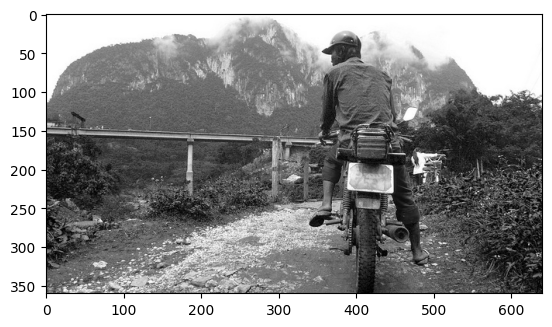

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.nn.functional import sigmoid, conv2d, relu
x = dt.getTrainTensor(0).to(device=device("cuda"))
mask = model.model.mask(x)
merge = (model.model.color.merge*x).sum(dim=1, keepdim=True)
downgrade: Tensor = relu(merge.expand(1, 64, x.shape[-2], x.shape[-1])+model.model.color.bias.expand(1, 64, x.shape[-2], x.shape[-1]))
# score = model.model.feat.bbx(color[:, 0:4, :, :])[:, 0:1, :, :]
print(downgrade.shape)

x= downgrade[:, 1:2, :, :]
# x = score
print(x.shape, x.min(), x.max())
x = x-x.min()
x = x/x.max()
x = x.repeat(1, 3, 1, 1)
plt.imshow(TensorToImg(x.detach().to(device("cpu"))))


tensor(0.5000, device='cuda:0') tensor(486.4661, device='cuda:0') tensor(220.5347, device='cuda:0')


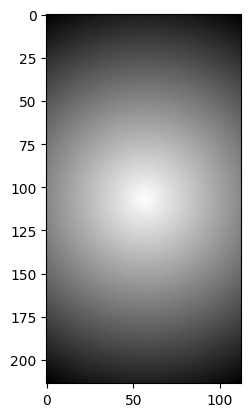

In [ ]:
from torch import arange, tensor, float as tfloat, device
label = dt.getTrainLabel(0).unsqueeze(0).to(device=device("cuda"))
label = label.squeeze().squeeze()
X1, Y1, X2, Y2 = label[0:4]
X1 = X1.floor().long()
X2 = X2.ceil().long()
Y1 = Y1.floor().long()
Y2 = Y2.ceil().long()
scores = model.model(dt.getTrainTensor(0).to(device=device("cuda")))
B, C, H, W = scores.shape
score = scores[:, 0:1, :, :]
w = scores[:, 1:2, :, :]
h = scores[:, 2:3, :, :]
row = arange(H, device=label.device, dtype=tfloat).view(1,1,H,1).expand(1,1,H,W)
col = arange(W, device=label.device, dtype=tfloat).view(1,1,1,W).expand(1,1,H,W)
x1 = (col-w).floor()
x2 = (col+w).ceil()
y1 = (row-h).floor()
y2 = (row+h).ceil()
pred_box = score[:, :, Y1:Y2, X1:X2]
center = tensor([(X1+X2)/2, (Y1+Y2)/2], device=label.device, dtype=tfloat).view(2, 1, 1, 1, 1).expand(2, 1,1,H,W)
distance = ((row-center[1]).square() + (col-center[0]).square()).sqrt()
print(distance.min(), distance.max(), distance.mean())
target = distance[:, :, Y1:Y2, X1:X2]
target = 1-target/target.max()
target = target.repeat(1, 3, 1, 1)
import matplotlib.pyplot as plt
plt.imshow(TensorToImg(target.detach().to(device("cpu"))))
plt.show()


In [ ]:

import torch
def pool2d(x, kernel_size=3, stride=1, padding=0) -> torch.Tensor:
    if padding > 0:
        x = torch.nn.functional.pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    patches = torch.nn.functional.unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.view(B, C, kernel_size * kernel_size, -1)
    median = patches.mode(dim=2).values
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return median.view(B, C, H_out, W_out)

def count(x, kernel_size=3, stride=1, padding=0) -> torch.Tensor:
    if padding > 0:
        x = torch.nn.functional.pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    weight = torch.tensor([256*256, 256, 1], device=x.device).view(1, 3, 1, 1)
    x = (x* weight).sum(dim=1, keepdim=True)
    patches = torch.nn.functional.unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.permute(0, 2, 1)
    count = patches.mode(dim=-1, keepdim=True).values
    print(count.shape, patches.shape)
    count = (patches[:, :]==count[:, :]).sum(dim=-1)
    
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return count.view(B, 1, H_out, W_out)

torch.Size([1, 230400, 1]) torch.Size([1, 230400, 25])
tensor([[[[25, 25, 25,  ..., 25, 25, 25],
          [25, 25, 25,  ..., 25, 25, 25],
          [25, 25, 25,  ..., 25, 25, 25],
          ...,
          [ 8, 10, 11,  ..., 10, 12, 11],
          [ 8, 10, 10,  ..., 11, 11, 12],
          [ 6,  8,  8,  ...,  9, 12, 13]],

         [[25, 25, 25,  ..., 25, 25, 25],
          [25, 25, 25,  ..., 25, 25, 25],
          [25, 25, 25,  ..., 25, 25, 25],
          ...,
          [ 8, 10, 11,  ..., 10, 12, 11],
          [ 8, 10, 10,  ..., 11, 11, 12],
          [ 6,  8,  8,  ...,  9, 12, 13]],

         [[25, 25, 25,  ..., 25, 25, 25],
          [25, 25, 25,  ..., 25, 25, 25],
          [25, 25, 25,  ..., 25, 25, 25],
          ...,
          [ 8, 10, 11,  ..., 10, 12, 11],
          [ 8, 10, 10,  ..., 11, 11, 12],
          [ 6,  8,  8,  ...,  9, 12, 13]]]], device='cuda:0')


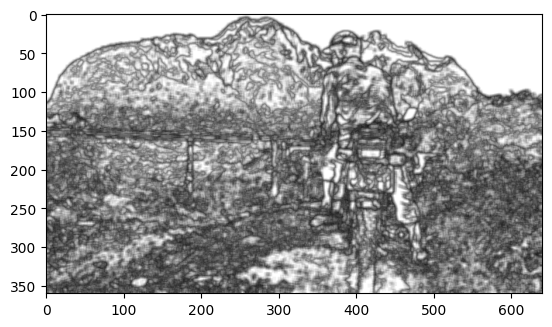

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
x = dt.getTrainTensor(0).to(device=torch.device("cuda"))
x = ((x*255/64).round()*64).clamp(max=255)/255
c = count(x, 5, 1, 2).repeat(1, 3, 1, 1)
print(c)
x = c/c.max()
# x = pool2d(x, 11, 1, 5)
# x = x/x.max()
plt.imshow(TensorToImg(x.detach().to(torch.device("cpu"))))
plt.show()

torch.Size([1, 3, 402, 768])
tensor([[359.1700, 146.1700, 471.6200, 359.7400,   4.0000]])


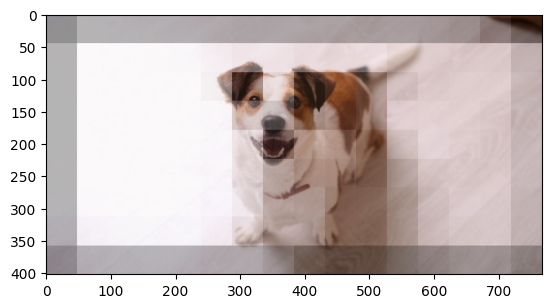

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
x = ImgToTensor(ImgRead("image2.png"))
print(x.shape)
# x = dt.getTrainTensor(0).to(device=torch.device("cpu"))
print(dt.getTrainLabel(0))
# score: Tensor = model.model(x)
B, C, H, W = x.shape
percent = 1
size = 3
# score = torch.zeros_like(x)
# for i in range(5):
#     color = torch.nn.functional.avg_pool2d(x, kernel_size=size, stride=size, padding=size//2)
#     color = torch.nn.functional.interpolate(color, size=(H, W), mode="nearest")
#     # color = (color- x).abs()
#     # color = 1 - color/color.max()
#     score = score + color
#     percent*=1.5
    # size*=3
# color = torch.nn.functional.avg_pool2d(x, kernel_size=25, stride=1, padding=12)
# color = torch.nn.functional.interpolate(color, size=(H, W), mode="nearest")
# color = (color- x).abs()
# x = score
color = x
color = torch.nn.functional.avg_pool2d(x, kernel_size=50, stride=50, padding=25)
color = torch.nn.functional.interpolate(color, size=(H, W), mode="nearest")
x = color + x
x = x-x.min()
x = x/x.max()
# x=score/score.max()
plt.imshow(TensorToImg(x.to(torch.device("cpu"))))
plt.show()
# for mat in ls:
#     mat = torch.softmax(mat, dim=-1)
#     side *= 5
#     M, I = mat.max(dim=-1)
#     indices = (M > 0.6) & (I>0)
#     H, W = mat.shape[1:3]
#     row = torch.arange(H, device=x.device).view(1, H, 1).expand(1, H, W)
#     col = torch.arange(W, device=x.device).view(1, 1, W).expand(1, H, W)
#     # print(mat.shape)
#     label = mat[:, :, :, 4]
#     print(I[indices], M[indices])
#     position = torch.stack([row, col], dim=-1)[indices].to(device=device("cpu"))
#     for i in position:
#         rect = patches.Rectangle([i[1]*side,i[0]*side], side, side, edgecolor='red', facecolor='none')
#         plt.subplot().add_patch(rect)
# plt.show()s
